Original Dataset:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

Customer Summary:
   Customer ID  TotalAmount  Frequency
0      12346.0       -51.74         47
1      12347.0      4921.53        222
2      12348.0      2019.40         51
3      12349.0      

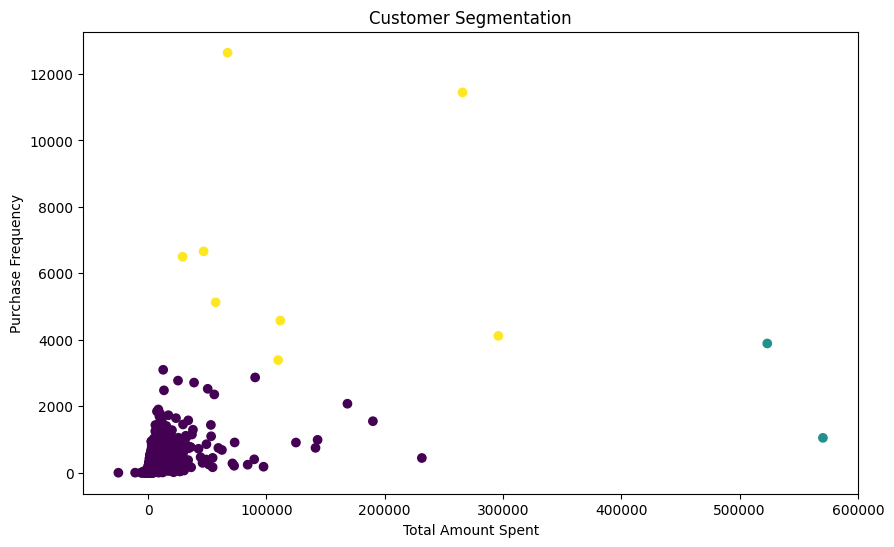

In [3]:
# Customer Purchase Behaviour Analysis - Python Part

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load Dataset
file_path = "/content/online_retail_II.csv"
df = pd.read_csv("/content/online_retail_II.csv")

# Show First 5 Rows
print("Original Dataset:")
print(df.head())

# Remove Missing Values
df = df.dropna()

# Remove Duplicates
df = df.drop_duplicates()

# Create TotalAmount Column
df["TotalAmount"] = df["Quantity"] * df["Price"]

# Customer Spending Analysis
customer_df = df.groupby("Customer ID").agg({
    "TotalAmount": "sum",
    "Invoice": "count"
}).reset_index()

customer_df.rename(columns={"Invoice": "Frequency"}, inplace=True)

print("\nCustomer Summary:")
print(customer_df.head())

# Feature Selection
X = customer_df[["TotalAmount", "Frequency"]]

# Standardize Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
customer_df["Cluster"] = kmeans.fit_predict(X_scaled)

# Assign Labels
cluster_labels = {
    0: "Medium Customers",
    1: "Premium Customers",
    2: "Regular Customers"
}
customer_df["CustomerSegment"] = customer_df["Cluster"].map(cluster_labels)

# Show Final Output
print("\nClustered Customers:")
print(customer_df.head(20))

# Plot Customer Segments
plt.figure(figsize=(10,6))
plt.scatter(customer_df["TotalAmount"], customer_df["Frequency"], c=customer_df["Cluster"])
plt.xlabel("Total Amount Spent")
plt.ylabel("Purchase Frequency")
plt.title("Customer Segmentation")
plt.show()